In [1]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
metric_mapping = {
    'sanity.data_mismatch.score': 'DataMismatchScore',
    'sanity.common_rows_proportion.score': 'CommonRowsProportion',
    'sanity.nearest_syn_neighbor_distance.mean': 'NearestSyntheticNeighborDistance',
    'sanity.close_values_probability.score': 'CloseValuesProbability',
    'sanity.distant_values_probability.score': 'DistantValuesProbability',
    'stats.jensenshannon_dist.marginal': 'JensenShannonDistance',
    'stats.chi_squared_test.marginal': 'ChiSquaredTest',
    'stats.inv_kl_divergence.marginal': 'InverseKLDivergence',
    'stats.ks_test.marginal': 'KolmogorovSmirnovTest',
    'stats.max_mean_discrepancy.joint': 'MaximumMeanDiscrepancy',
    'stats.wasserstein_dist.joint': 'WassersteinDistance',
    'stats.prdc.precision': 'PRDCScore',
    'stats.prdc.recall': 'PRDCScore',
    'stats.prdc.density': 'PRDCScore',
    'stats.prdc.coverage': 'PRDCScore',
    'stats.alpha_precision.delta_precision_alpha_OC': 'AlphaPrecision',
    'stats.alpha_precision.delta_coverage_beta_OC': 'AlphaPrecision',
    'stats.alpha_precision.authenticity_OC': 'AlphaPrecision',
    'stats.alpha_precision.delta_precision_alpha_naive': 'AlphaPrecision',
    'stats.alpha_precision.delta_coverage_beta_naive': 'AlphaPrecision',
    'stats.alpha_precision.authenticity_naive': 'AlphaPrecision',
    'performance.linear_model.syn_id': 'AugmentationPerformanceEvaluatorLinear',
    'performance.linear_model.syn_ood': 'AugmentationPerformanceEvaluatorLinear',
    'performance.mlp.syn_id': 'AugmentationPerformanceEvaluatorMLP',
    'performance.mlp.syn_ood': 'AugmentationPerformanceEvaluatorMLP',
    'performance.xgb.syn_id': 'AugmentationPerformanceEvaluatorXGB',
    'performance.xgb.syn_ood': 'AugmentationPerformanceEvaluatorXGB',
    'performance.feat_rank_distance.corr': 'FeatureImportanceRankDistance',
    'performance.feat_rank_distance.pvalue': 'FeatureImportanceRankDistance',
    'detection.detection_xgb.mean': 'SyntheticDetectionXGB',
    'detection.detection_mlp.mean': 'SyntheticDetectionMLP',
    'detection.detection_gmm.mean': 'SyntheticDetectionGMM',
    'detection.detection_linear.mean': 'SyntheticDetectionLinear',
    'privacy.delta-presence.score': 'DeltaPresence',
    'privacy.k-anonymization.syn': 'kAnonymization',
    'privacy.k-map.score': 'kMap',
    'privacy.distinct l-diversity.syn': 'lDiversityDistinct',
    'privacy.identifiability_score.score': 'IdentifiabilityScore',
    'privacy.identifiability_score.score_OC': 'IdentifiabilityScore'
}

In [3]:
direction_mapping = {'CloseValuesProbability': 'maximize',
 'CommonRowsProportion': 'minimize',
 'DataMismatchScore': 'minimize',
 'DistantValuesProbability': 'minimize',
 'MetricEvaluator': None,
 'NearestSyntheticNeighborDistance': 'minimize',
 'AlphaPrecision': 'maximize',
 'ChiSquaredTest': 'maximize',
 'FrechetInceptionDistance': 'minimize',
 'InverseKLDivergence': 'maximize',
 'JensenShannonDistance': 'minimize',
 'KolmogorovSmirnovTest': 'maximize',
 'MaximumMeanDiscrepancy': 'minimize',
 'PRDCScore': 'maximize',
 'StatisticalEvaluator': None,
 'SurvivalKMDistance': 'minimize',
 'WassersteinDistance': 'minimize',
 'AugmentationPerformanceEvaluatorLinear': 'maximize',
 'AugmentationPerformanceEvaluatorMLP': 'maximize',
 'AugmentationPerformanceEvaluatorXGB': 'maximize',
 'FeatureImportanceRankDistance': 'minimize',
 'PerformanceEvaluator': 'maximize',
 'PerformanceEvaluatorLinear': 'maximize',
 'PerformanceEvaluatorMLP': 'maximize',
 'PerformanceEvaluatorXGB': 'maximize',
 'DetectionEvaluator': 'minimize',
 'SyntheticDetectionGMM': 'minimize',
 'SyntheticDetectionLinear': 'minimize',
 'SyntheticDetectionMLP': 'minimize',
 'SyntheticDetectionXGB': 'minimize',
 'DeltaPresence': 'maximize',
 'DomiasMIA': 'minimize',
 'DomiasMIABNAF': 'minimize',
 'DomiasMIAKDE': 'minimize',
 'DomiasMIAPrior': 'minimize',
 'IdentifiabilityScore': 'minimize',
 'PrivacyEvaluator': None,
 'kAnonymization': 'maximize',
 'kMap': 'maximize',
 'lDiversityDistinct': 'maximize',
 'AttackEvaluator': None,
 'DataLeakageLinear': 'minimize',
 'DataLeakageMLP': 'minimize',
 'DataLeakageXGB': 'minimize'}

In [4]:
dataset_name = 'cervical'

In [5]:
def get_data_syn_evalution_results(dataset_name, results_path='../results/*.csv'):
    files = glob(results_path)
    names = [file.split('/')[-1].split('.')[0] for file in  files]
    results = []
    for file, name in zip(files, names):
        if name.startswith(dataset_name):
            results.append(file)
    return results
    

In [6]:
files = get_data_syn_evalution_results(dataset_name)

In [7]:
files

['../results/cervical_dummy_sampler.csv',
 '../results/cervical_pategan.csv',
 '../results/cervical_ctgan.csv',
 '../results/cervical_tvae.csv',
 '../results/cervical_arf.csv',
 '../results/cervical_nflow.csv',
 '../results/cervical_rtvae.csv',
 '../results/cervical_dpgan.csv',
 '../results/cervical_marginal_distributions.csv',
 '../results/cervical_adsgan.csv',
 '../results/cervical_decaf.csv',
 '../results/cervical_ddpm.csv',
 '../results/cervical_uniform_sampler.csv']

In [8]:
def make_complete_evaluation_of_dataset_syn(files, dataset_name):
    """
    prepares the generated results by privgen_evaluation.ipynb
    for plotting
    """
    names = [
        file.split('/')[-1].split('.')[0].split('_', 1)[1] for file in files # there should be a more intelligent way to do this
    ]
    df_list = []
    for file in files:
        name = file.split('/')[-1].split('.')[0].split('_', 1)[1]
        temp = pd.read_csv(file)
        temp['synthesizer'] = name
        df_list.append(temp)

    df = pd.concat(df_list)
    df['dataset_name'] = dataset_name
    return df

In [9]:
comp_eval = make_complete_evaluation_of_dataset_syn(files, dataset_name)

In [10]:
def melt_evaluation_results(comp_eval):
    """reshaping data """
    melted_df = pd.melt(
    comp_eval,
    id_vars=[col for col in comp_eval.columns if col not in ['orig', 'privgen']],  # Keep all other columns
    value_vars=['orig', 'privgen'],  # Columns to stack
    var_name='Source',  # New column indicating whether the value is from 'orig' or 'privgen'
    value_name='Value'  # New column with the values
)
    return melted_df

In [11]:
melted = melt_evaluation_results(comp_eval)

In [12]:
def plot_metric_performance(melted):
    """
    Creates violin plots that show how the original data and privgen data are different for each metric
    """

    synths = melted['synthesizer'].unique().tolist()
    metrics = melted['Metric'].unique().tolist()

    for metric in metrics:
        temp = melted[melted['Metric'] == metric]
        clean_name = metric_mapping[metric]
        direction = direction_mapping[clean_name]

        sns.violinplot(x="Metric",
                       y="Value",
                       hue="Source",
                       data=temp,
                       palette="Pastel1").set_title(f'{clean_name}: {direction}')
        plt.show()

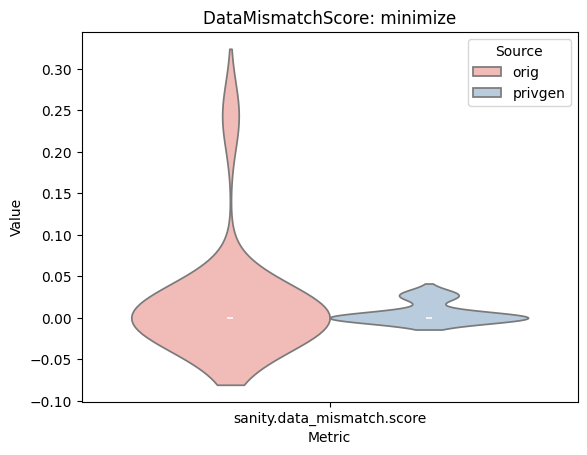

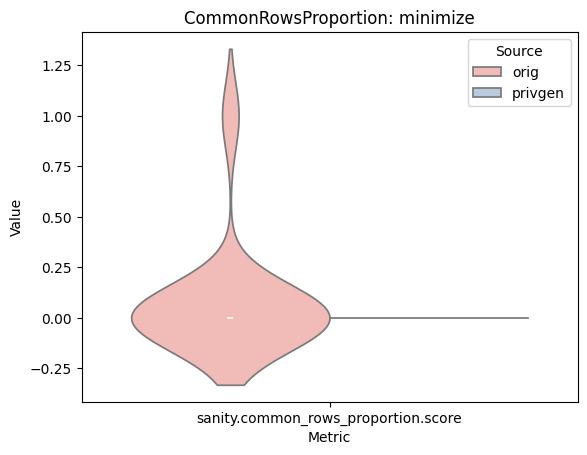

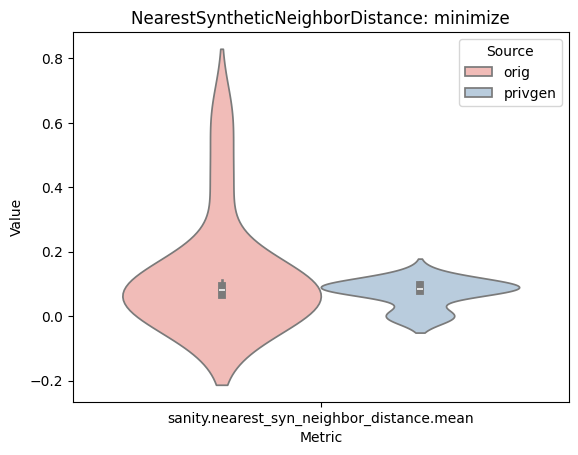

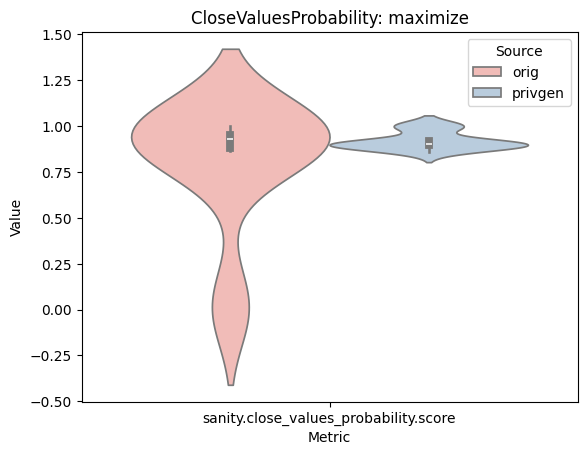

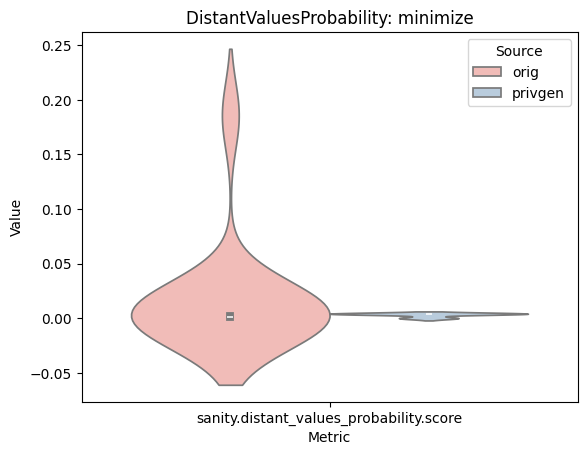

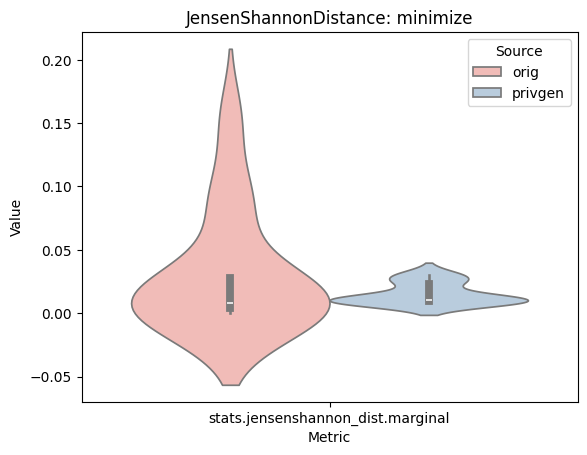

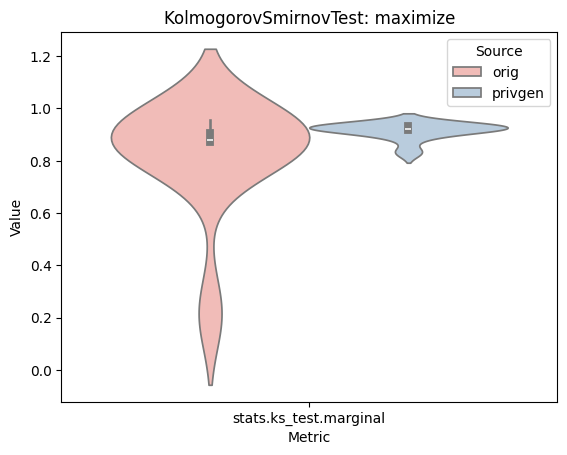

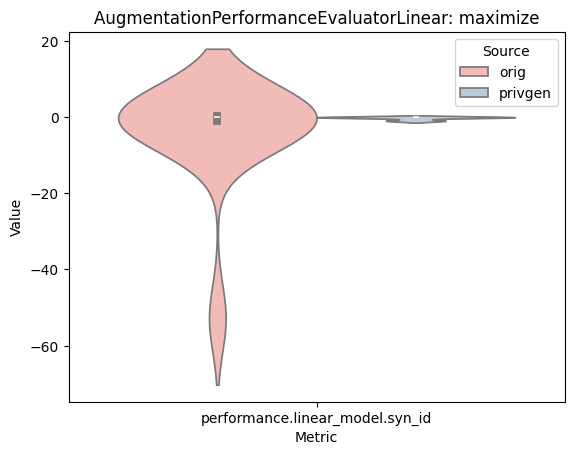

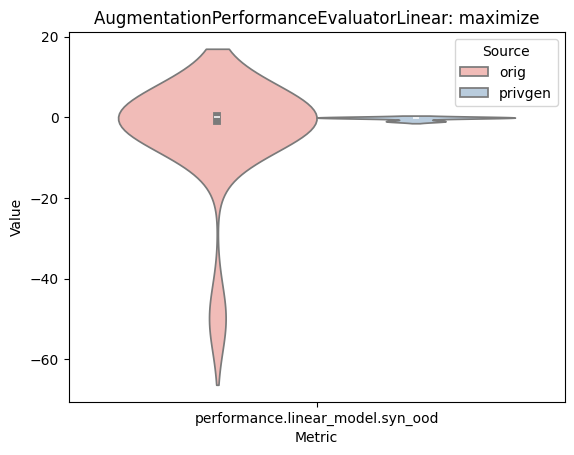

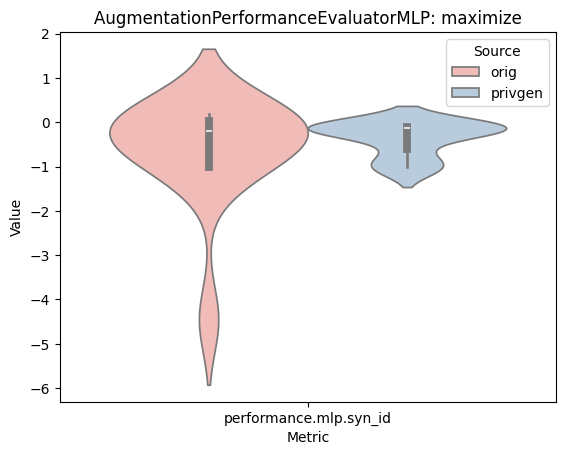

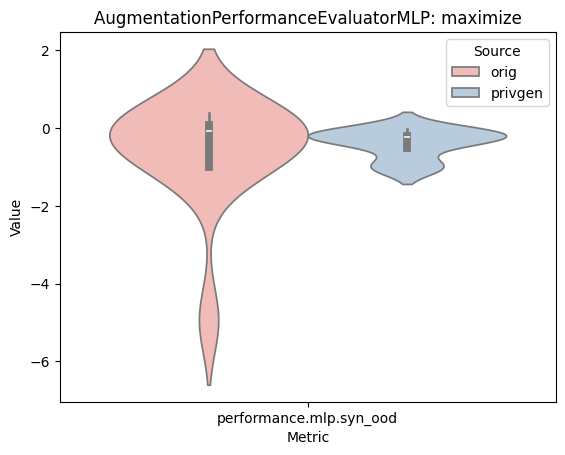

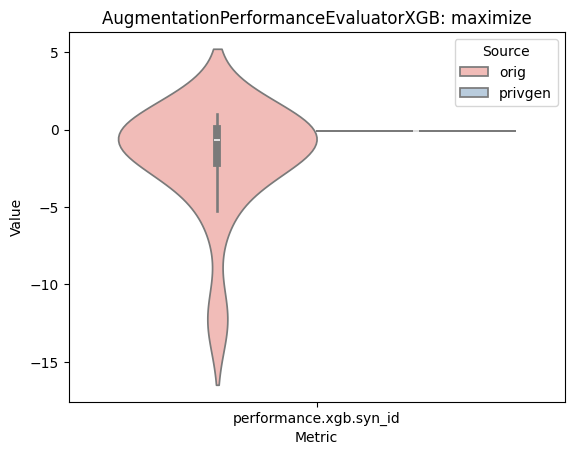

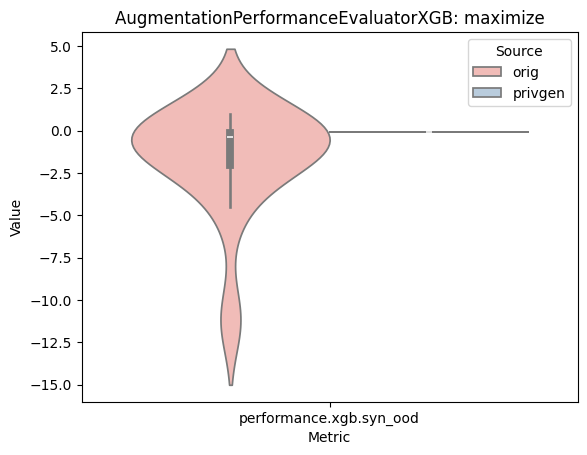

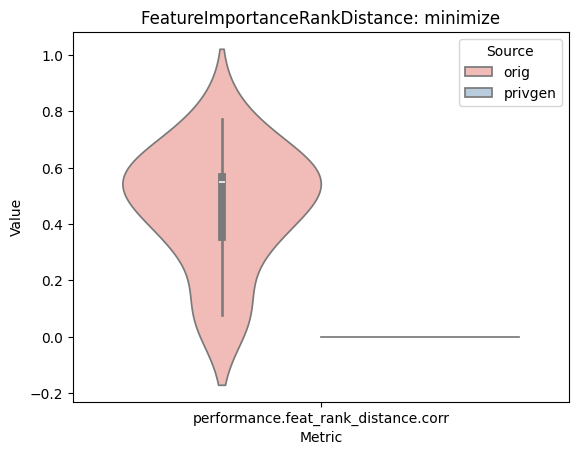

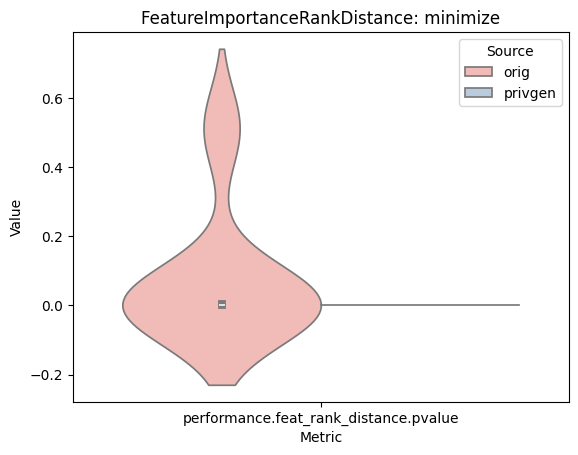

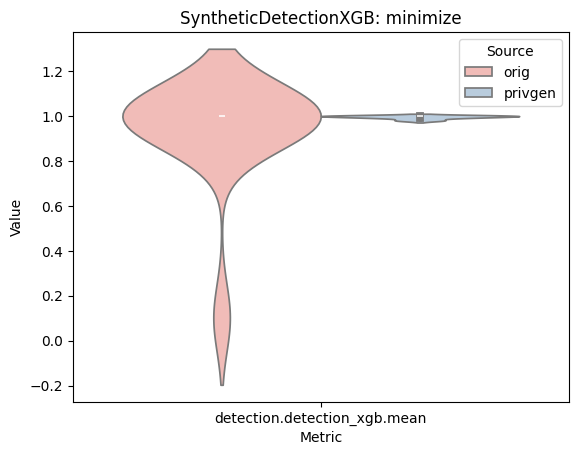

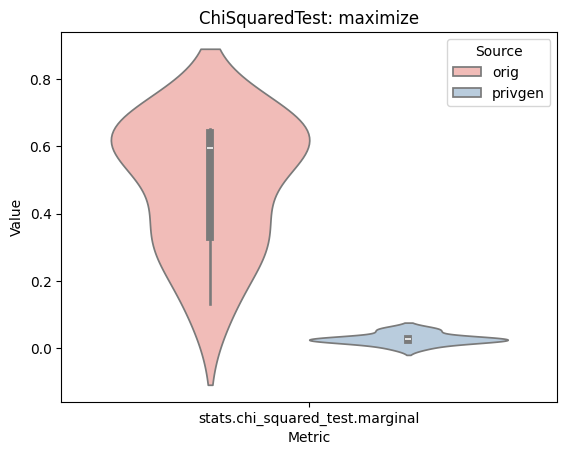

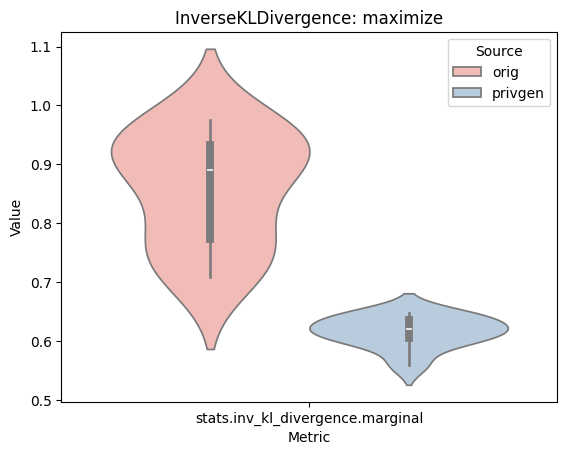

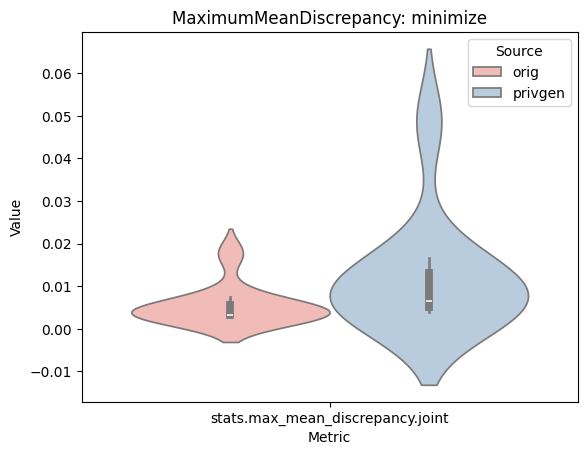

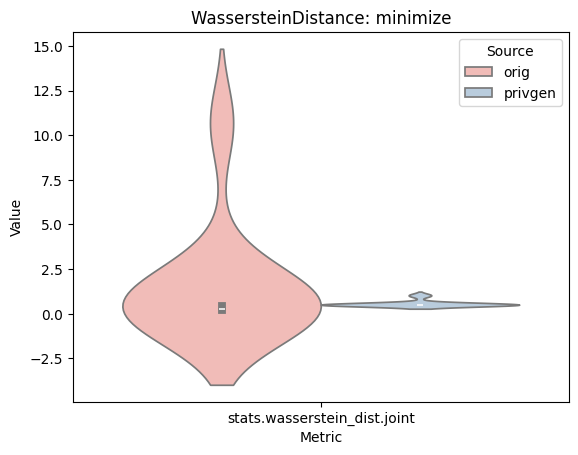

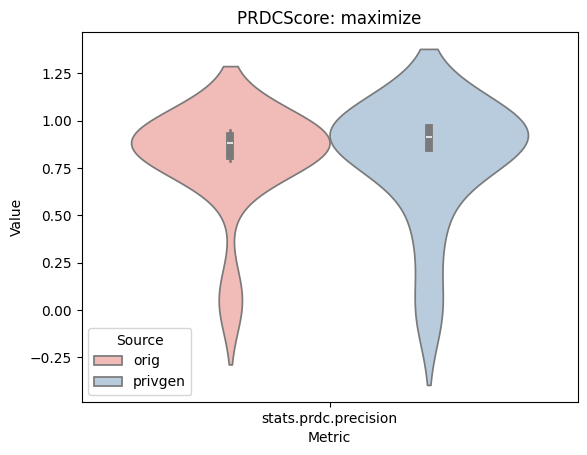

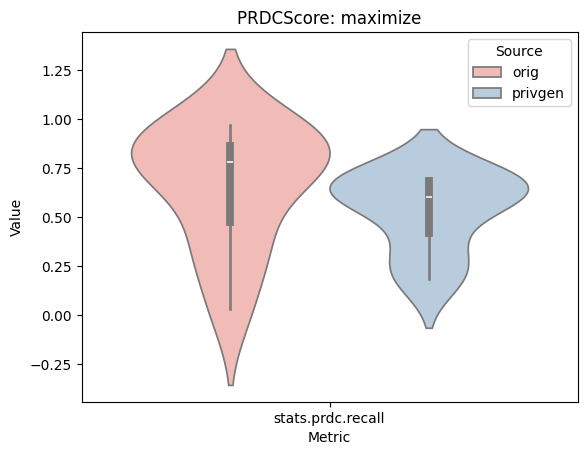

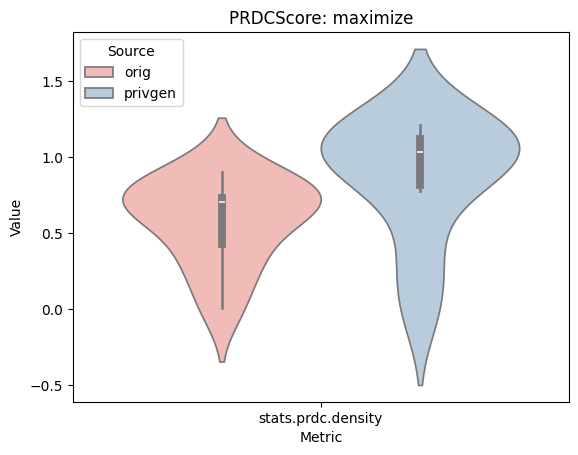

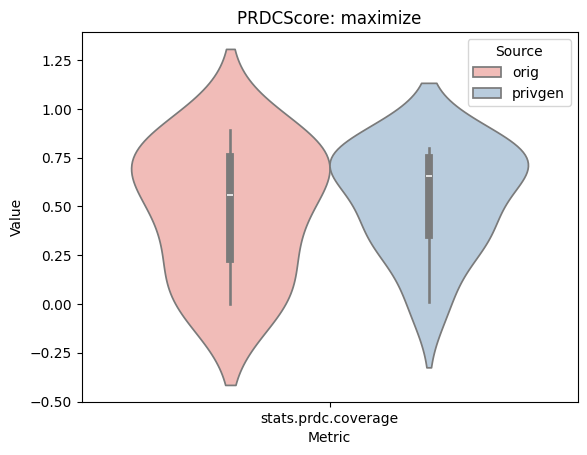

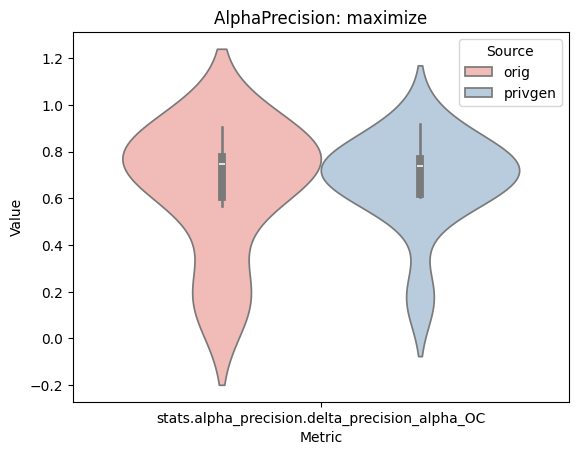

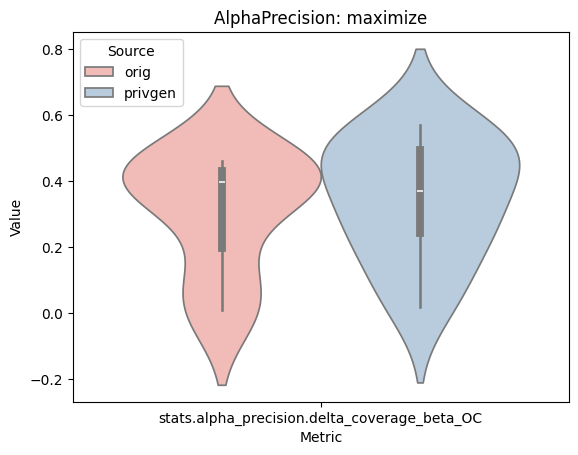

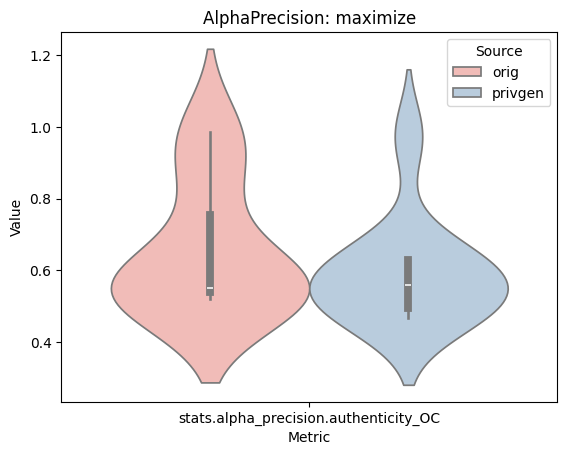

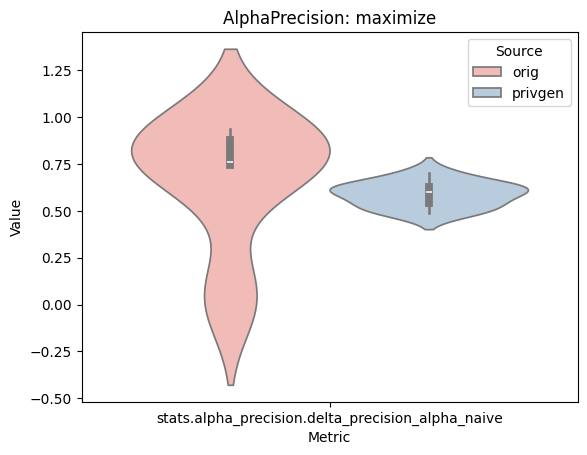

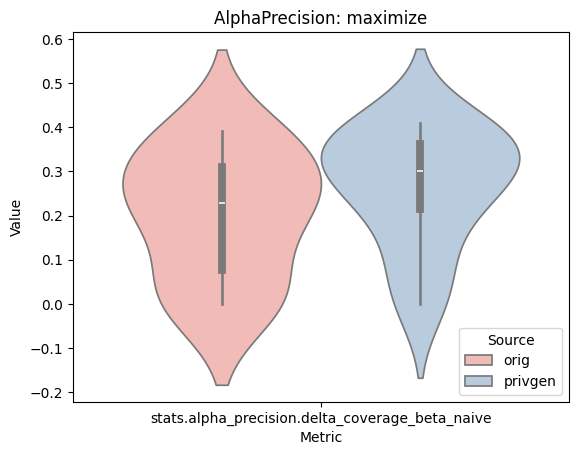

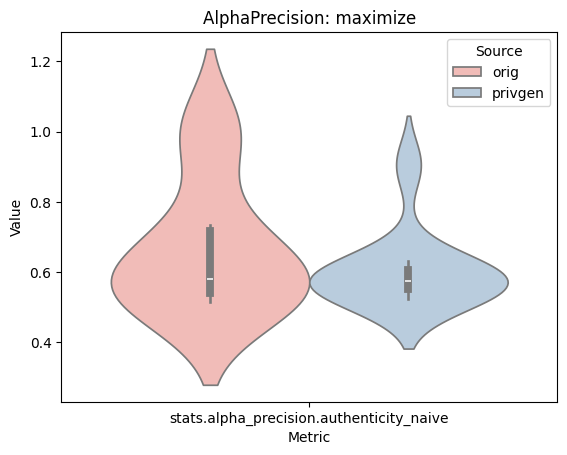

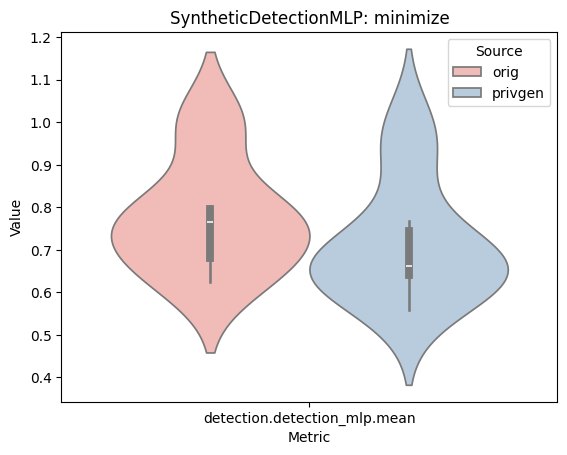

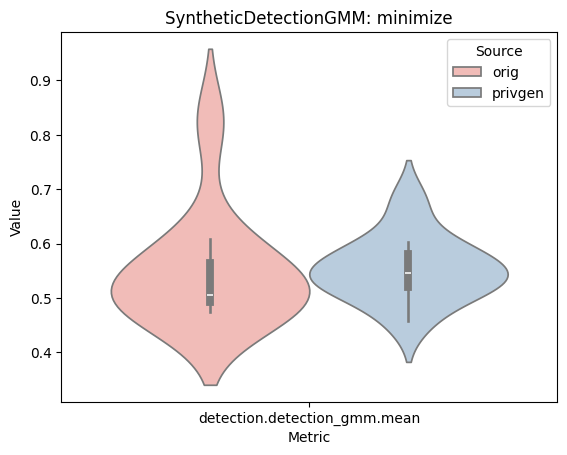

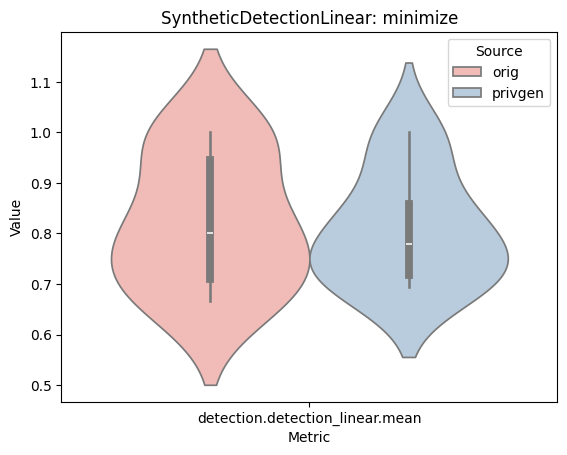

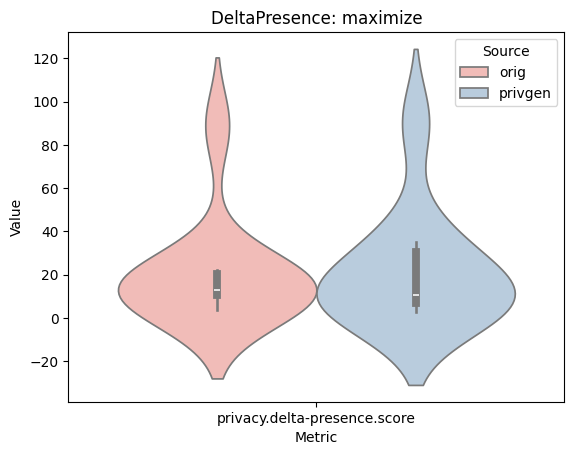

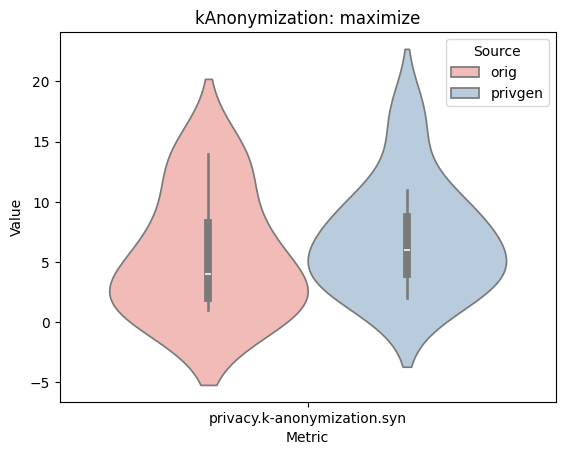

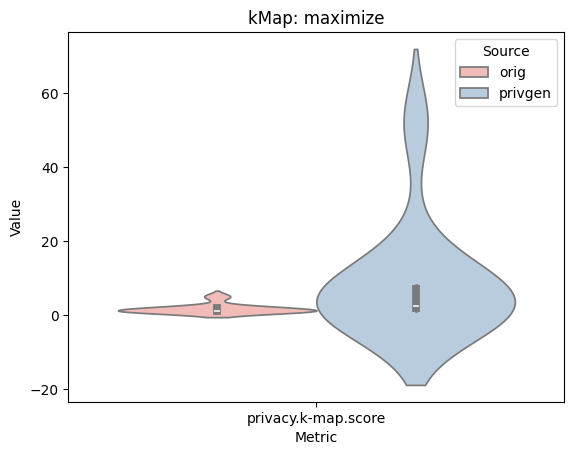

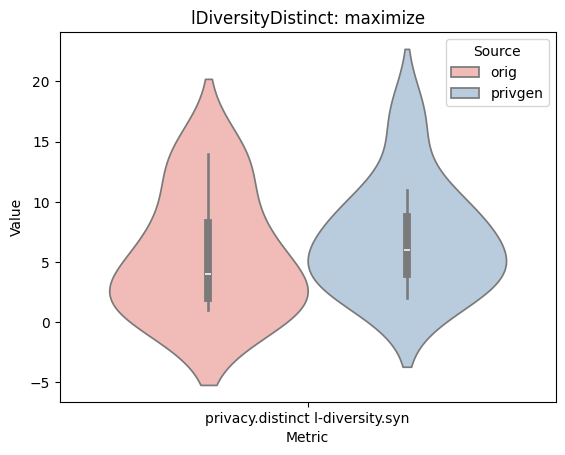

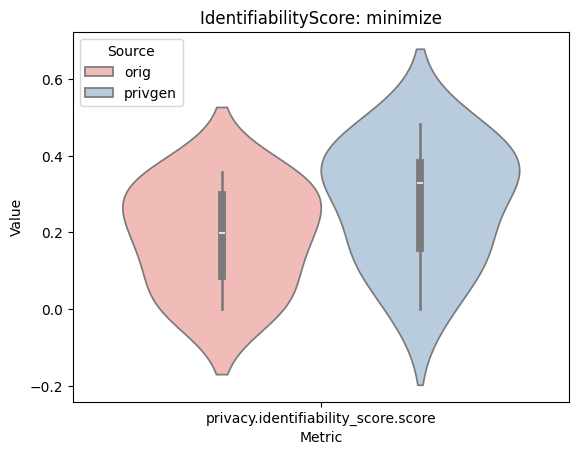

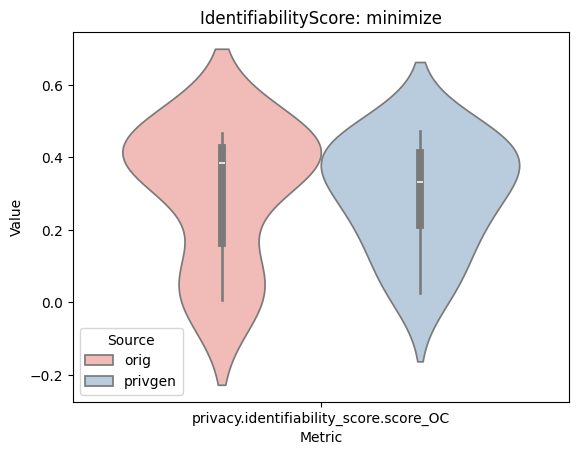

In [13]:
plot_metric_performance(melted)

In [14]:
def plot_metric_performance_2(melted, dataset_name, pdf_filename="performance.pdf"):
    # Extract category information
    melted['category'] = melted['Metric'].apply(lambda x: x.split('.')[0])
    categories = melted['category'].unique().tolist()

    for category in categories:
        # Filter data for the current category
        melted_temp = melted[melted['category'] == category]
        synths = melted_temp['synthesizer'].unique().tolist()
        metrics = melted_temp['Metric'].unique().tolist()

        # Calculate the grid size for subplots
        num_metrics = len(metrics)
        cols = 3  # Define the number of columns for the grid
        rows = math.ceil(num_metrics / cols)

        # Create a figure with the calculated grid size
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()

        for i, metric in enumerate(metrics):
            temp = melted_temp[melted_temp['Metric'] == metric]
            clean_name = metric_mapping[metric]
            direction = direction_mapping[clean_name]

            # Plotting the violin plot
            sns.violinplot(ax=axes[i],
            #sns.boxplot(ax=axes[i],
                           x="Metric",
                           y="Value",
                           hue="Source",
                           data=temp,
                           palette="Pastel1")
            
            axes[i].set_title(f'{clean_name}: {direction}')
            axes[i].legend(loc='best')

        # Turn off unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        # Add category title to the top center of the figure
        fig.suptitle(f'{dataset_name}: {category.upper()}', fontsize=26, fontweight='bold', y=1.02)

        # Adjust layout and save the figure
        plt.tight_layout()
        fig.savefig(f'../results_figures/{dataset_name}_{category}_{pdf_filename}', dpi=300, bbox_inches='tight')
        plt.show()

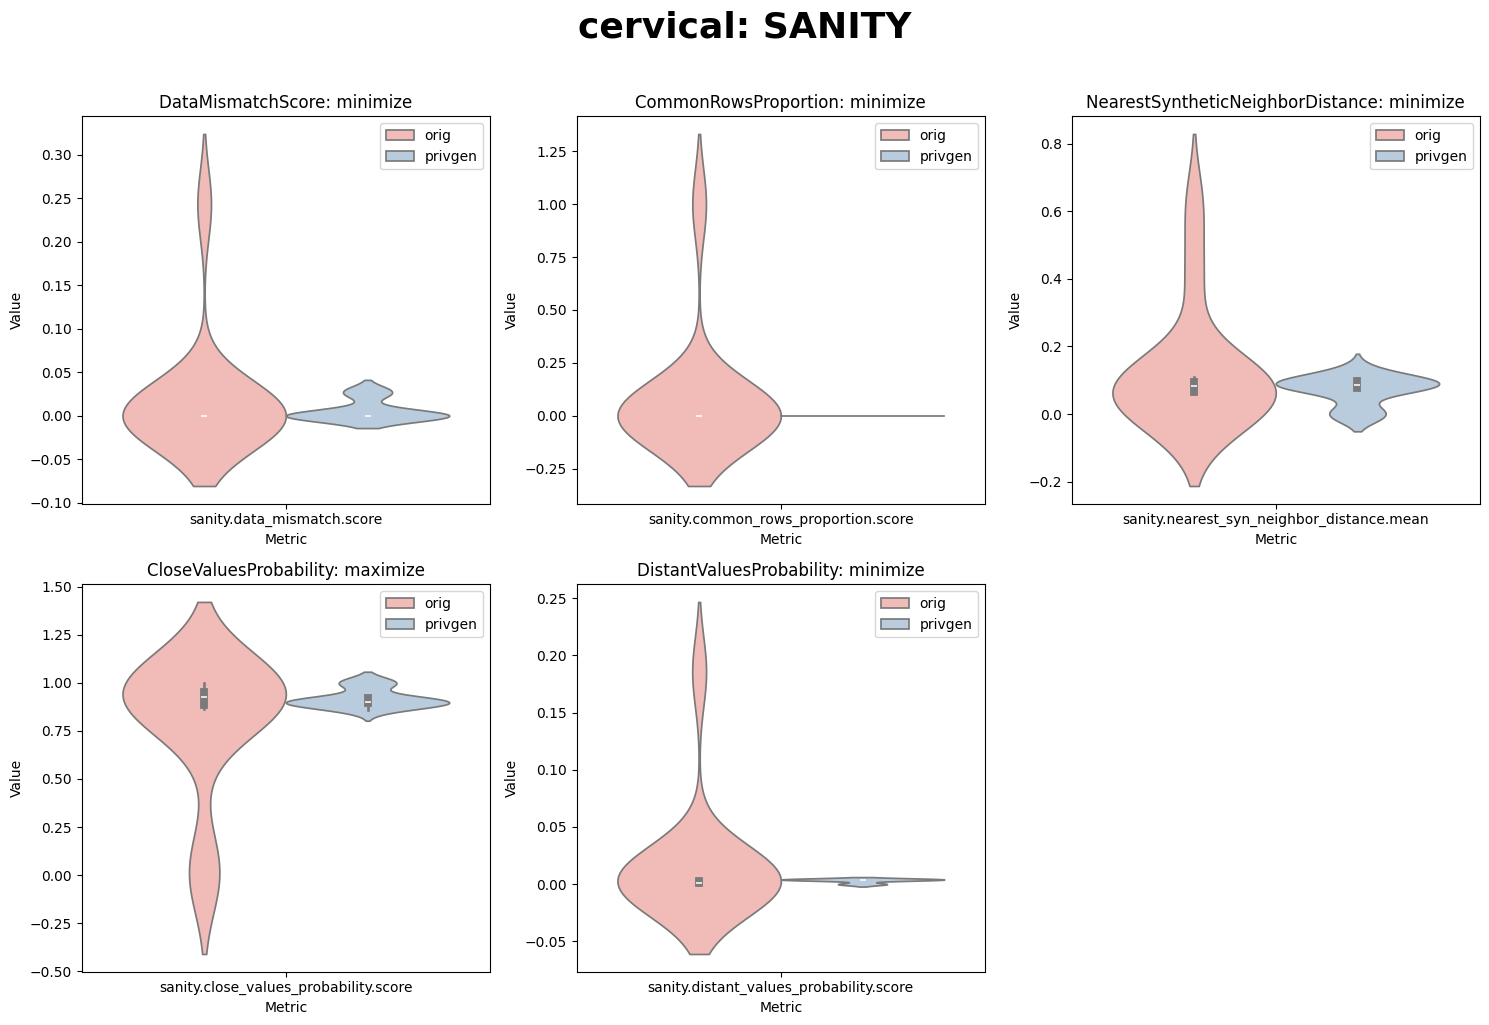

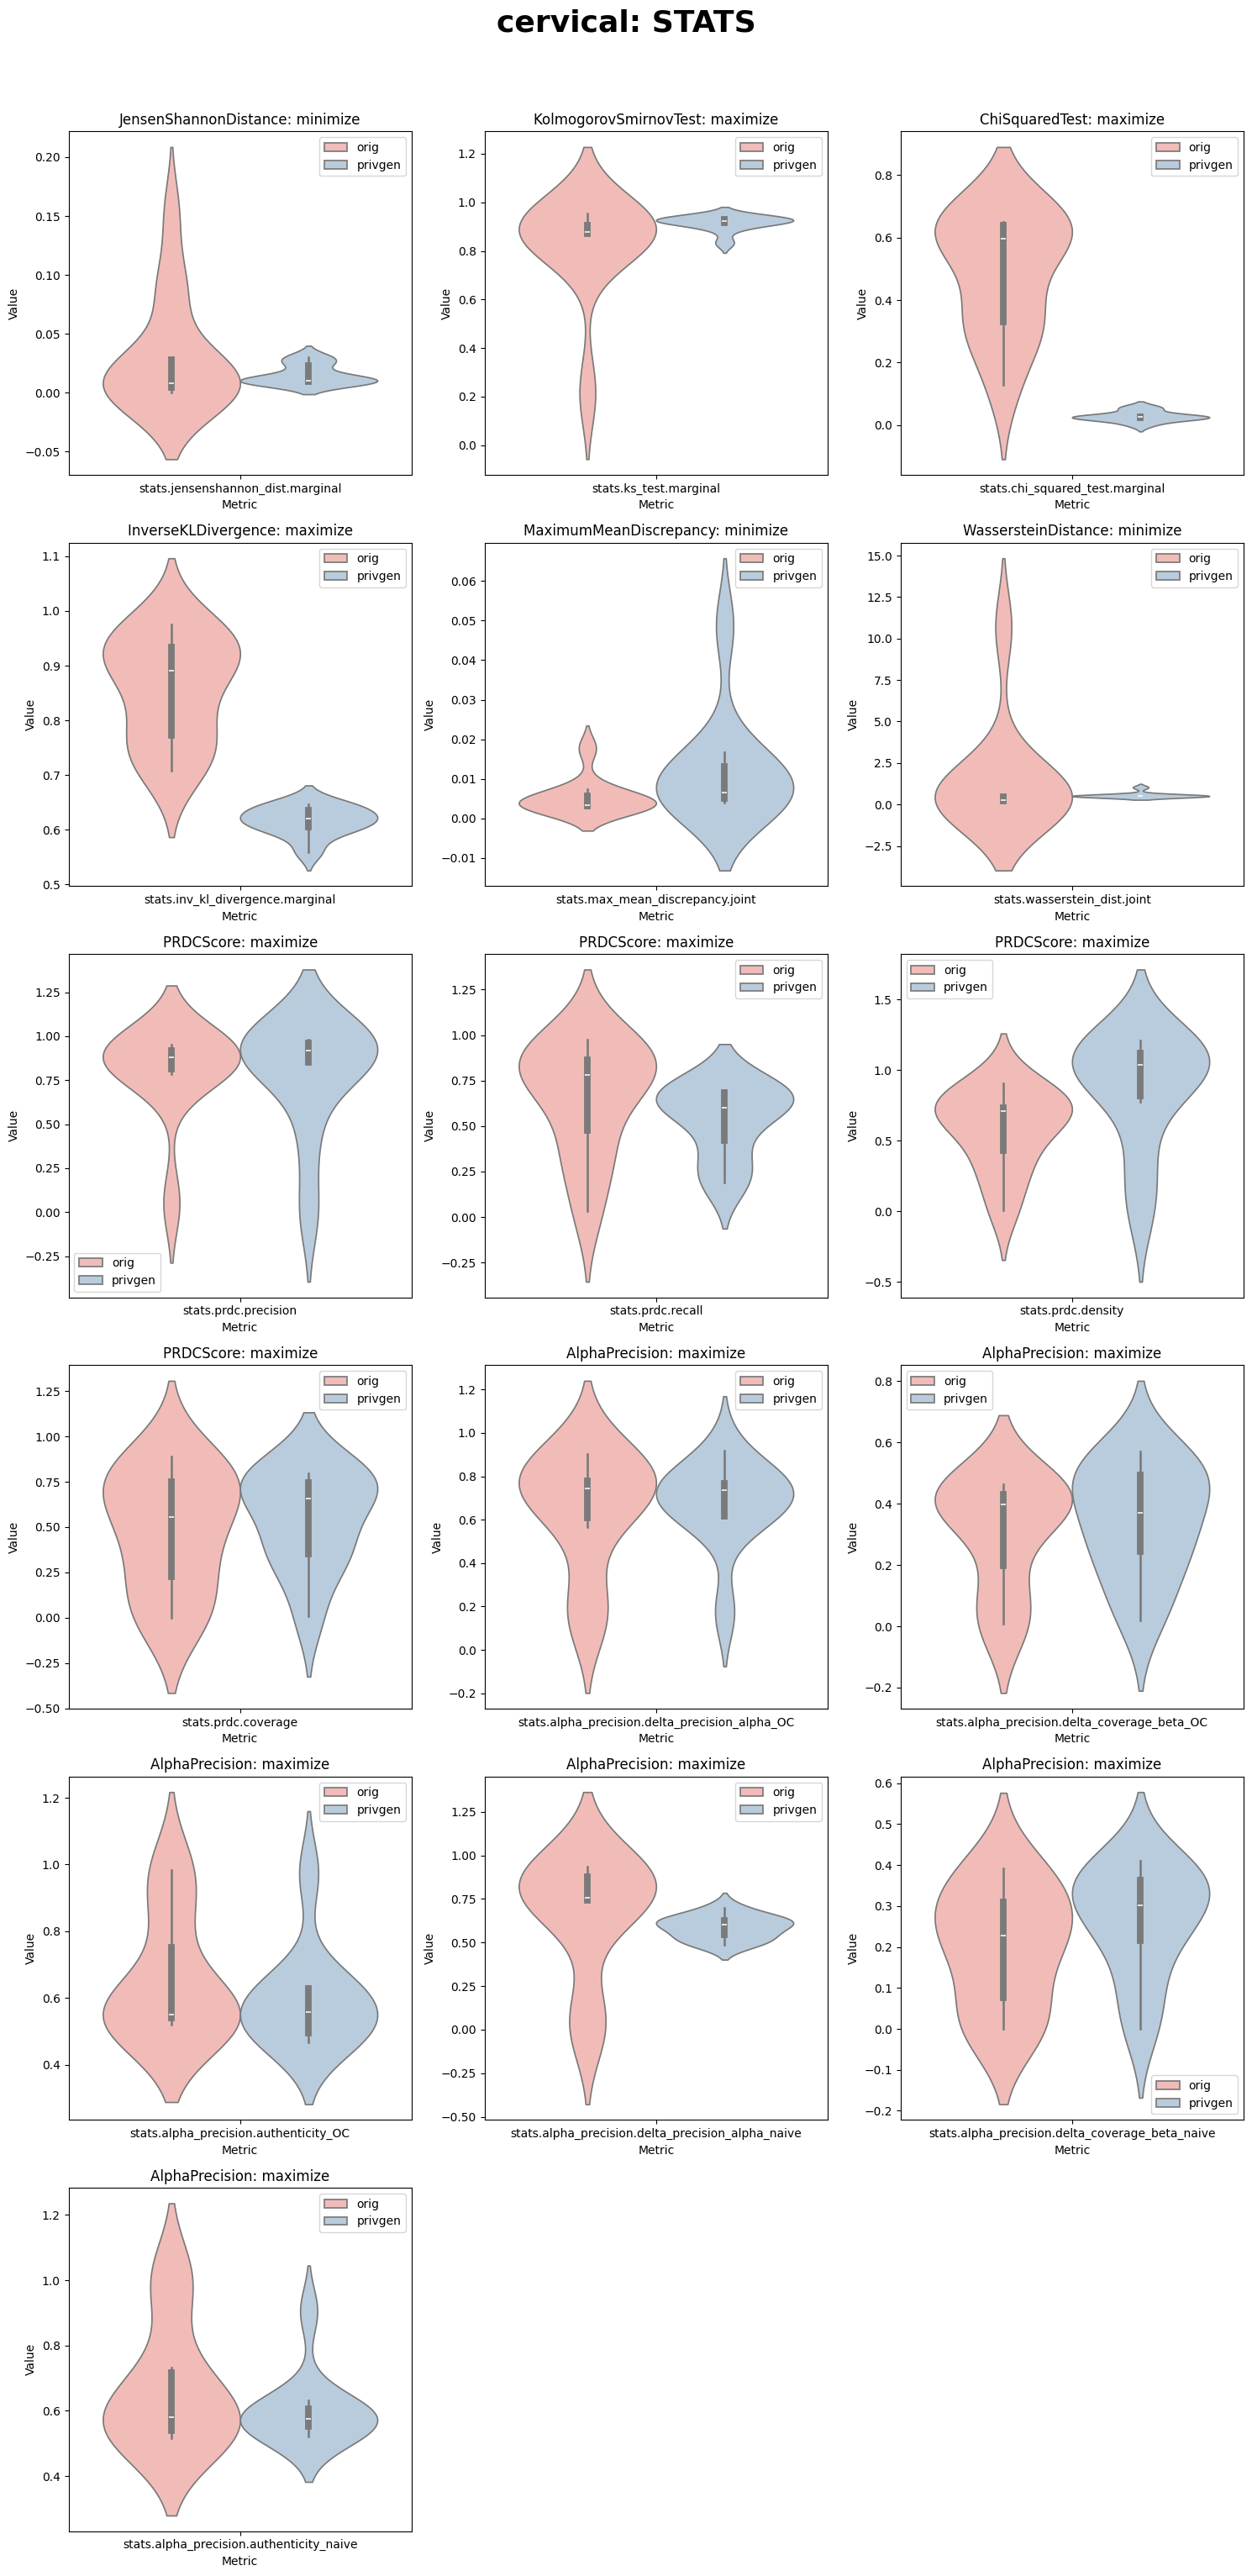

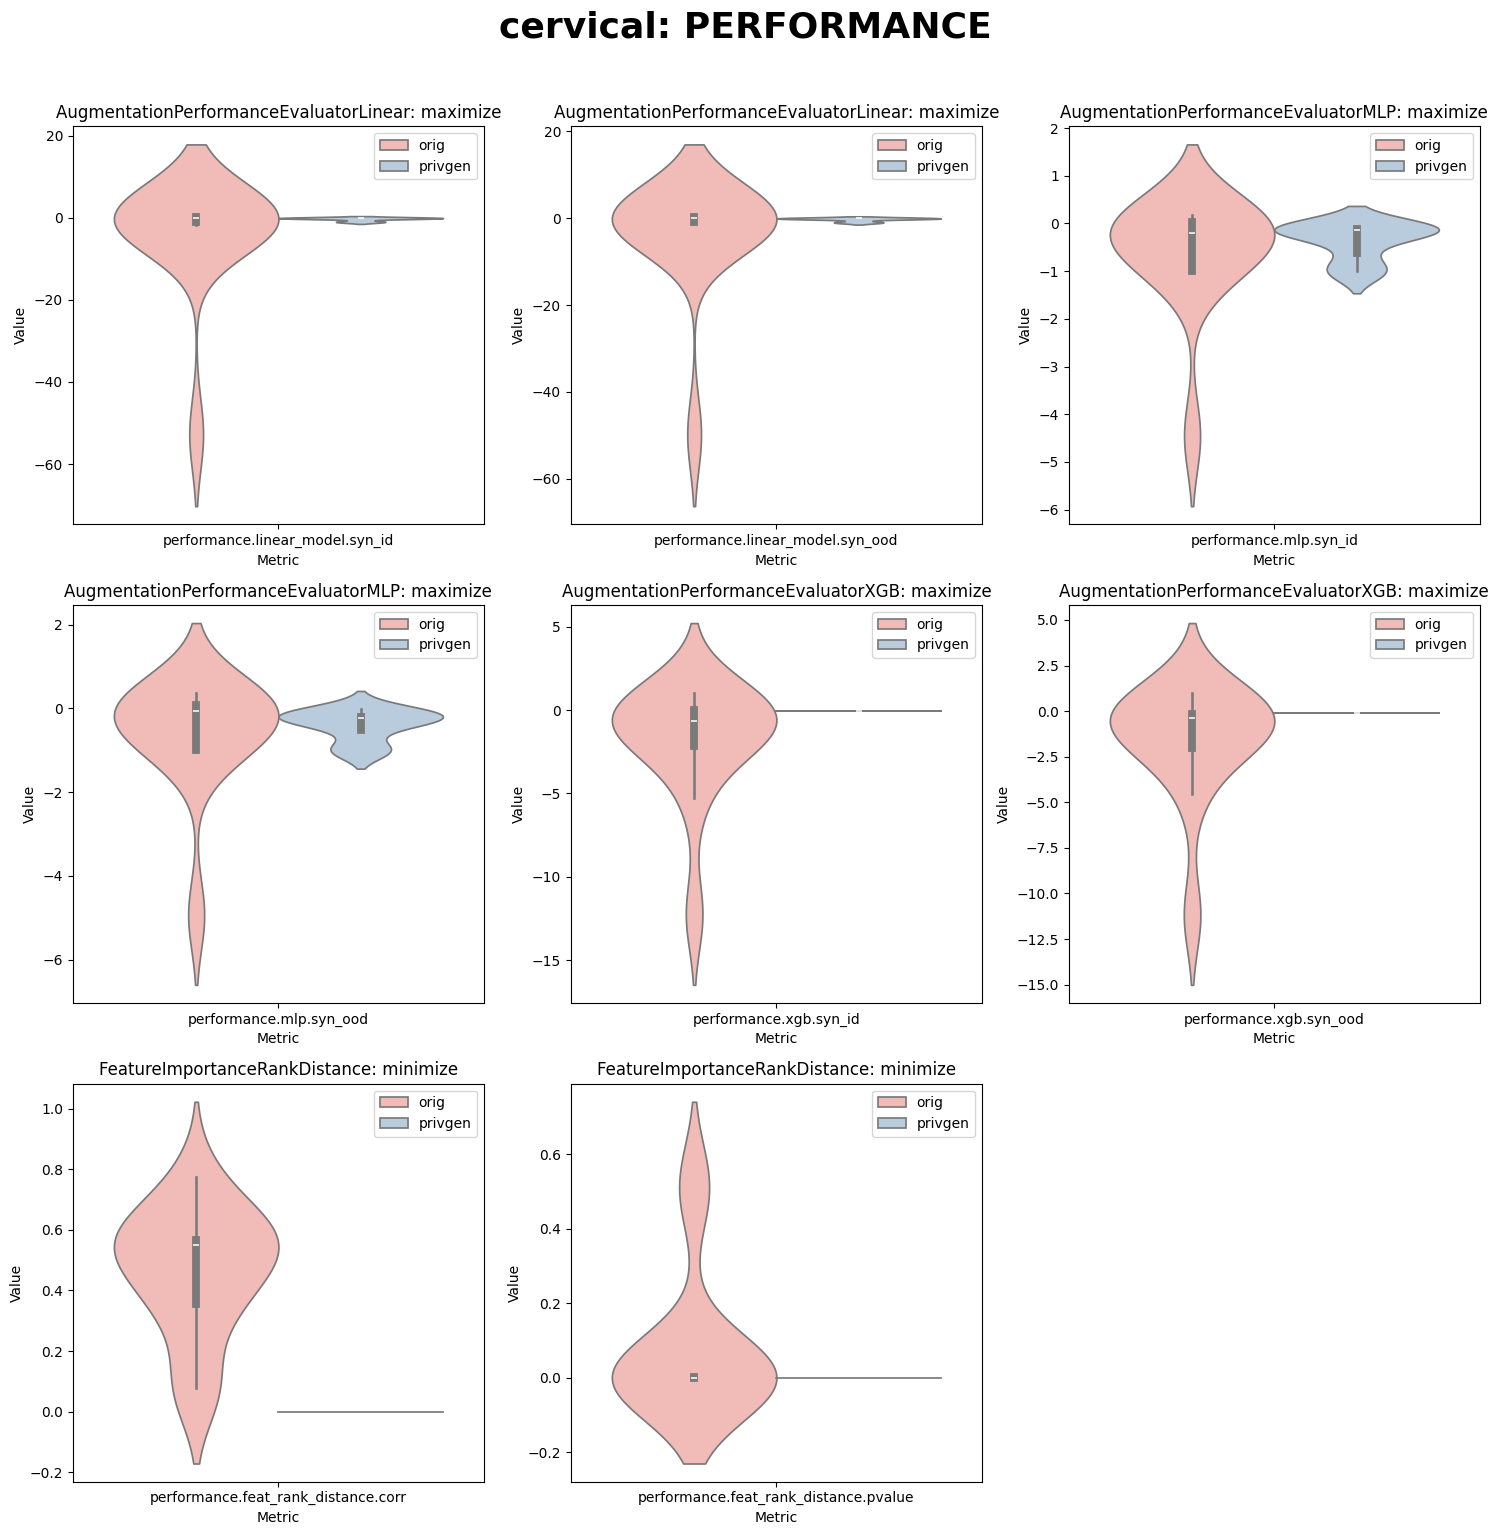

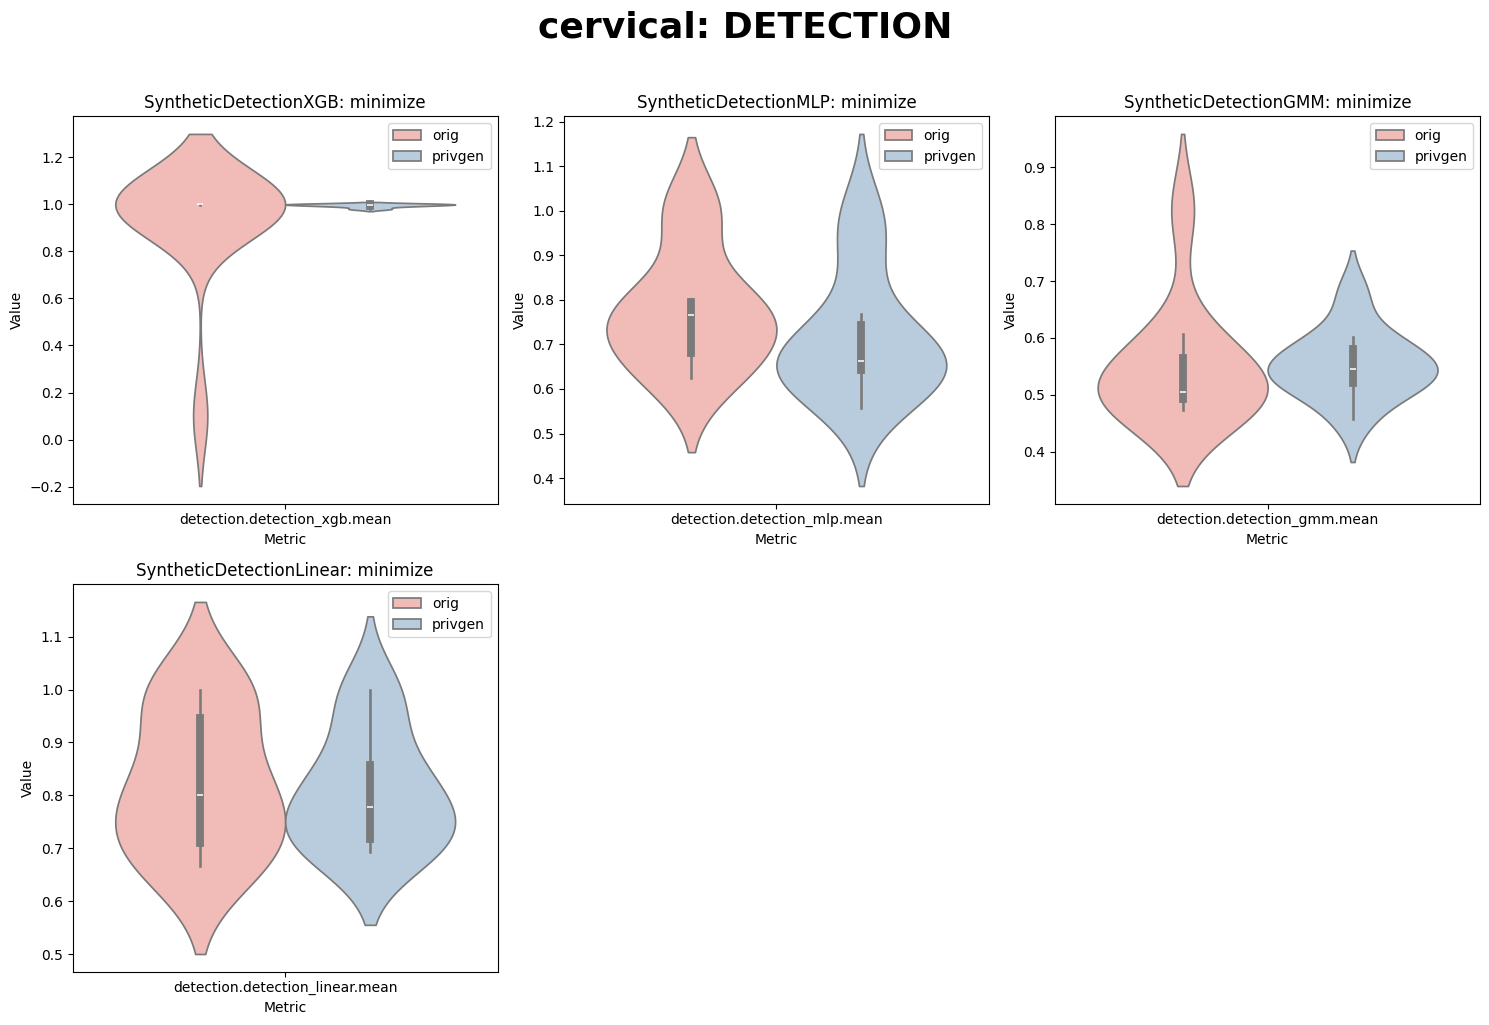

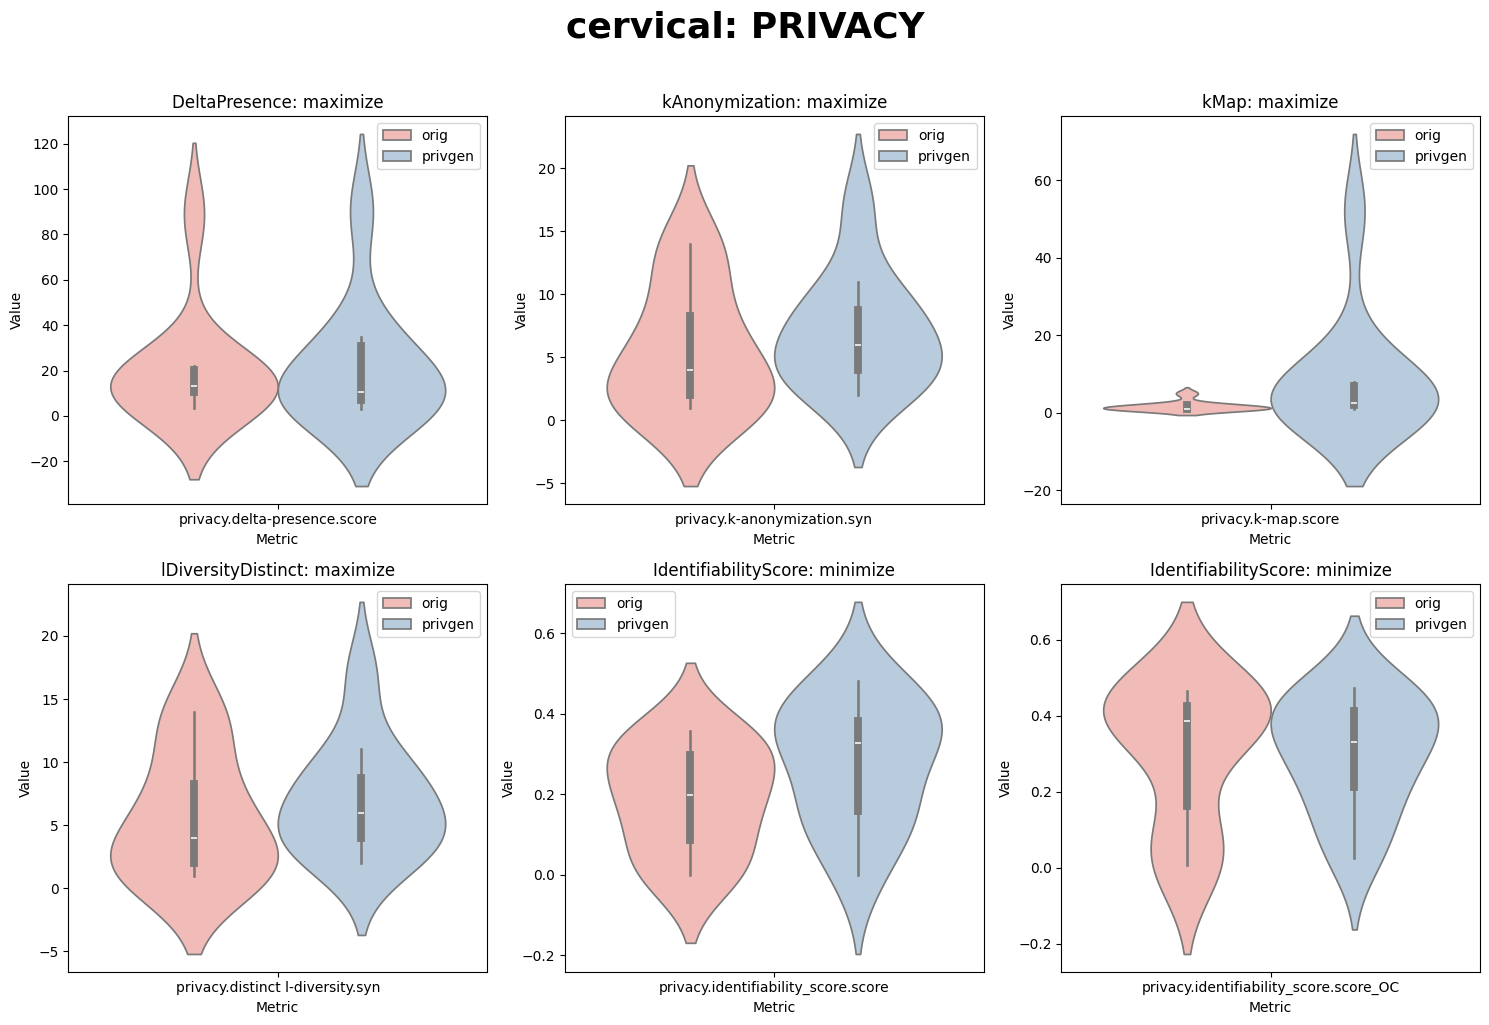

In [15]:
plot_metric_performance_2(melted, dataset_name)